## Predicting whether a song will be a hit or a flop!
### This is based on the Spotify hit predictor dataset on Kaggle

In [4]:
import pandas as pd
import numpy as np

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import scipy.stats as stats

In [7]:
from scipy.stats import mannwhitneyu

In [8]:
from scipy.stats import chi2_contingency

In [9]:
df_00s = pd.read_csv("../../spotify_hit_predictor/dataset-of-00s.csv")

In [10]:
df_10s = pd.read_csv("../../spotify_hit_predictor/dataset-of-10s.csv")
df_60s = pd.read_csv("../../spotify_hit_predictor/dataset-of-60s.csv")
df_70s = pd.read_csv("../../spotify_hit_predictor/dataset-of-70s.csv")
df_80s = pd.read_csv("../../spotify_hit_predictor/dataset-of-80s.csv")
df_90s = pd.read_csv("../../spotify_hit_predictor/dataset-of-90s.csv")

#### Datasets have been split by the decades, capturing that info as a field

In [12]:
df_00s['decade'] = "00s"
df_10s['decade'] = "10s"
df_60s['decade'] = "60s"
df_70s['decade'] = "70s"
df_80s['decade'] = "80s"
df_90s['decade'] = "90s"

In [13]:
df_all = pd.concat([df_00s, df_10s, df_60s, df_70s, df_80s, df_90s]).reset_index(drop = True)

In [11]:
df_all.tail()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,decade
41101,(You're A) Go Nowhere,Reagan Youth,spotify:track:4e86fqSFhqRQk3Z9hm7XHt,0.396,0.795,9,-6.070,0,0.2340,0.000928,0.000209,0.1820,0.762,152.943,82107,4,30.34109,6,0,90s
41102,La Fiebre de Norma,La Castañeda,spotify:track:43DFcnOZprnVlAFKwgBJ3e,0.621,0.655,9,-6.281,0,0.0309,0.050600,0.006260,0.0937,0.690,134.167,211653,4,34.89506,10,0,90s
41103,Good Times,Edie Brickell,spotify:track:6UPfnVoOq3y3BvapBIKs8J,0.562,0.314,10,-15.213,0,0.0298,0.440000,0.000011,0.1060,0.571,166.847,189827,4,21.11763,10,1,90s
41104,Inane,KMFDM,spotify:track:2Ao3Wi4raEOQfKQiU9EU8y,0.622,0.781,7,-6.080,1,0.0368,0.000101,0.755000,0.3830,0.214,120.051,330053,4,47.13558,11,0,90s
41105,You Can Make History (Young Again),Elton John,spotify:track:3ca91BX2k7GSzEUsx1mPgI,0.664,0.739,2,-9.005,1,0.0262,0.106000,0.054200,0.3330,0.458,92.257,293973,4,42.50341,14,1,90s


#### A little more info on the fields - 
- track: The Name of the track.

- artist: The Name of the Artist.

- uri: The resource identifier for the track.

- danceability: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable. 

- energy: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. 

- key: The estimated overall key of the track. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C?/D?, 2 = D, and so on. If no key was detected, the value is -1.

- loudness: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typical range between -60 and 0 db. 

- mode: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0.

- speechiness: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. 

- acousticness: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic. The distribution of values for this feature look like this:

- instrumentalness: Predicts whether a track contains no vocals. “Ooh” and “aah” sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly “vocal”. The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. The distribution of values for this feature look like this:

- liveness: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live.

- valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry).

- tempo: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration. 

- duration_ms:  The duration of the track in milliseconds.

- time_signature: An estimated overall time signature of a track. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure).

- chorus_hit: This the the author's best estimate of when the chorus would start for the track. Its the timestamp of the start of the third section of the track. This feature was extracted from the data received by the API call for Audio Analysis of that particular track.

- sections: The number of sections the particular track has. This feature was extracted from the data received by the API call for Audio Analysis of that particular track.

- target: The target variable for the track. It can be either '0' or '1'. '1' implies that this song has featured in the weekly list (Issued by Billboards) of Hot-100 tracks in that decade at least once and is therefore a 'hit'. '0' Implies that the track is a 'flop'.

      The author's condition of a track being 'flop' is as follows:

        - The track must not appear in the 'hit' list of that decade.
        - The track's artist must not appear in the 'hit' list of that decade.
        - The track must belong to a genre that could be considered non-mainstream and / or avant-garde. 
        - The track's genre must not have a song in the 'hit' list.
        - The track must have 'US' as one of its markets.

### Now let's explore these fields

In [14]:
## Some overall statistics
df_all.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,41106.000000,4.110600e+04,41106.000000,41106.000000,41106.000000,41106.000000
mean,0.539695,0.579545,5.213594,-10.221525,0.693354,0.072960,0.364197,0.154416,0.201535,0.542440,119.338249,2.348776e+05,3.893689,40.106041,10.475673,0.500000
std,0.177821,0.252628,3.534977,5.311626,0.461107,0.086112,0.338913,0.303530,0.172959,0.267329,29.098845,1.189674e+05,0.423073,19.005515,4.871850,0.500006
min,0.000000,0.000251,0.000000,-49.253000,0.000000,0.000000,0.000000,0.000000,0.013000,0.000000,0.000000,1.516800e+04,0.000000,0.000000,0.000000,0.000000
25%,0.420000,0.396000,2.000000,-12.816000,0.000000,0.033700,0.039400,0.000000,0.094000,0.330000,97.397000,1.729278e+05,4.000000,27.599792,8.000000,0.000000
50%,0.552000,0.601000,5.000000,-9.257000,1.000000,0.043400,0.258000,0.000120,0.132000,0.558000,117.565000,2.179070e+05,4.000000,35.850795,10.000000,0.500000
75%,0.669000,0.787000,8.000000,-6.374250,1.000000,0.069800,0.676000,0.061250,0.261000,0.768000,136.494000,2.667730e+05,4.000000,47.625615,12.000000,1.000000
max,0.988000,1.000000,11.000000,3.744000,1.000000,0.960000,0.996000,1.000000,0.999000,0.996000,241.423000,4.170227e+06,5.000000,433.182000,169.000000,1.000000


In [23]:
### Numerical vs categorical fields
numerical_cols = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','chorus_hit','sections']
categ_cols = ['key','mode','time_signature','decade']

In [25]:
### Coverting categorical column dtypes to object
for i in categ_cols:
    df_all[i] = df_all[i].astype('object')

In [27]:
### Treat the target column as well
df_all['target'] = df_all['target'].astype('object')

<Axes: xlabel='target', ylabel='count'>

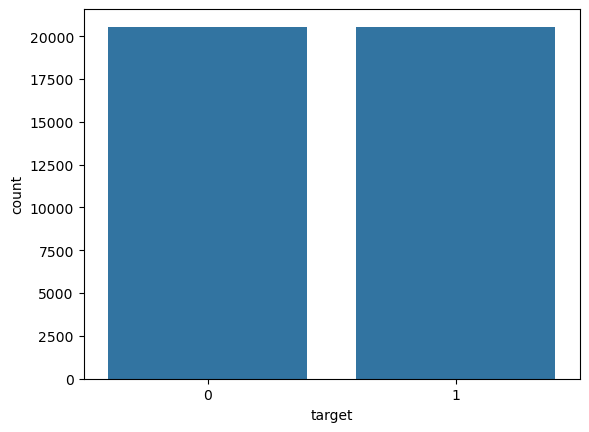

In [18]:
sns.countplot(df_all, x="target")

For Variable - danceability


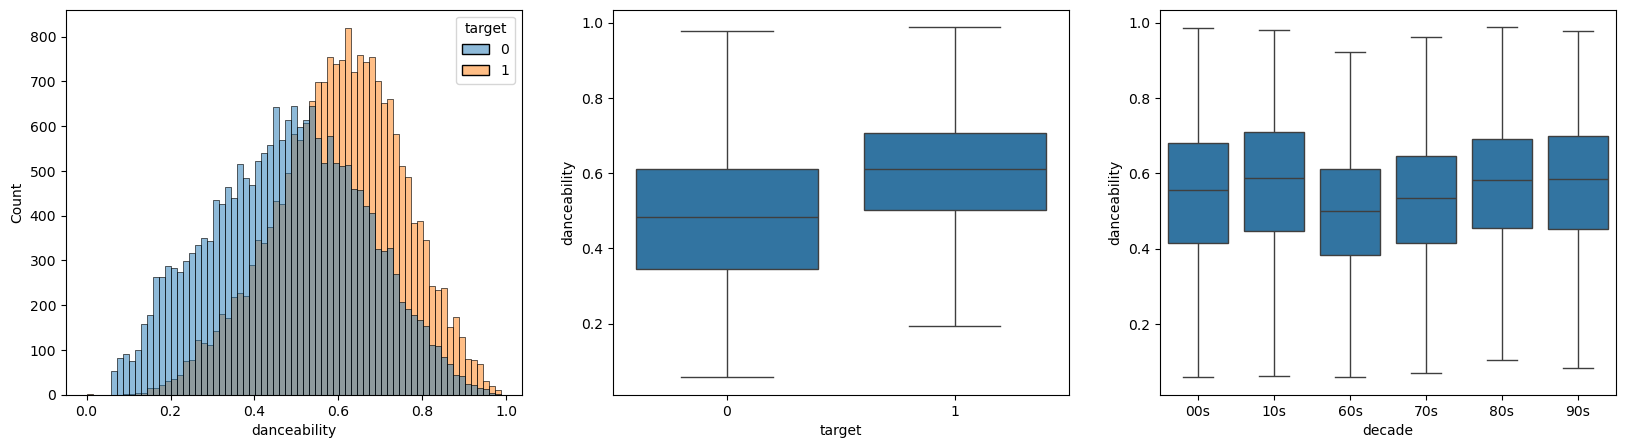

----------------------------------------------
For Variable - energy


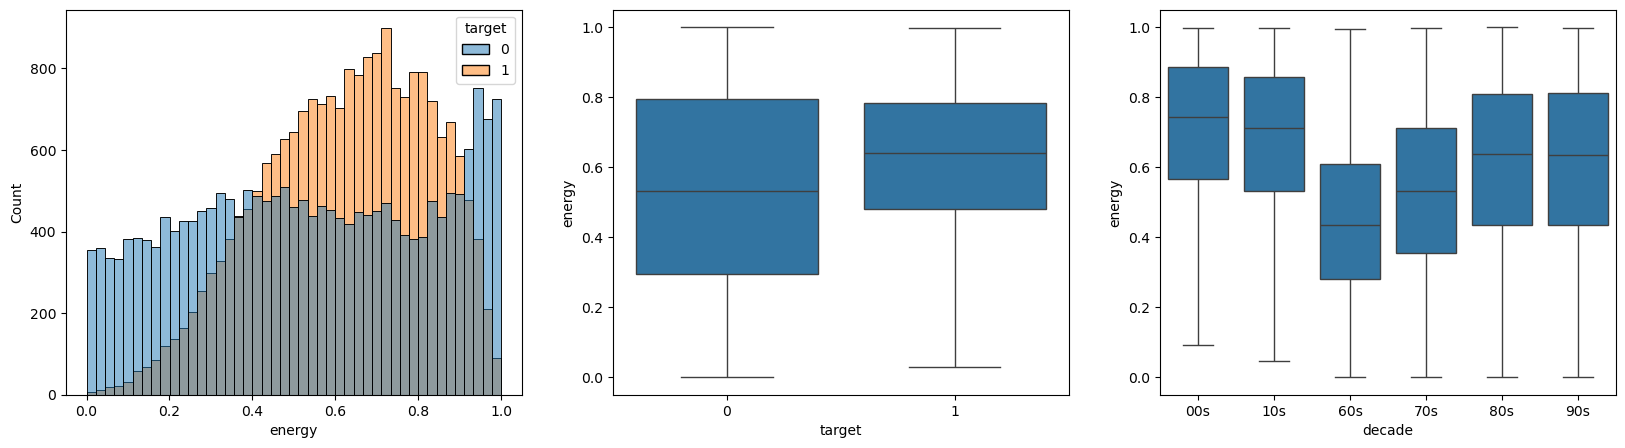

----------------------------------------------
For Variable - loudness


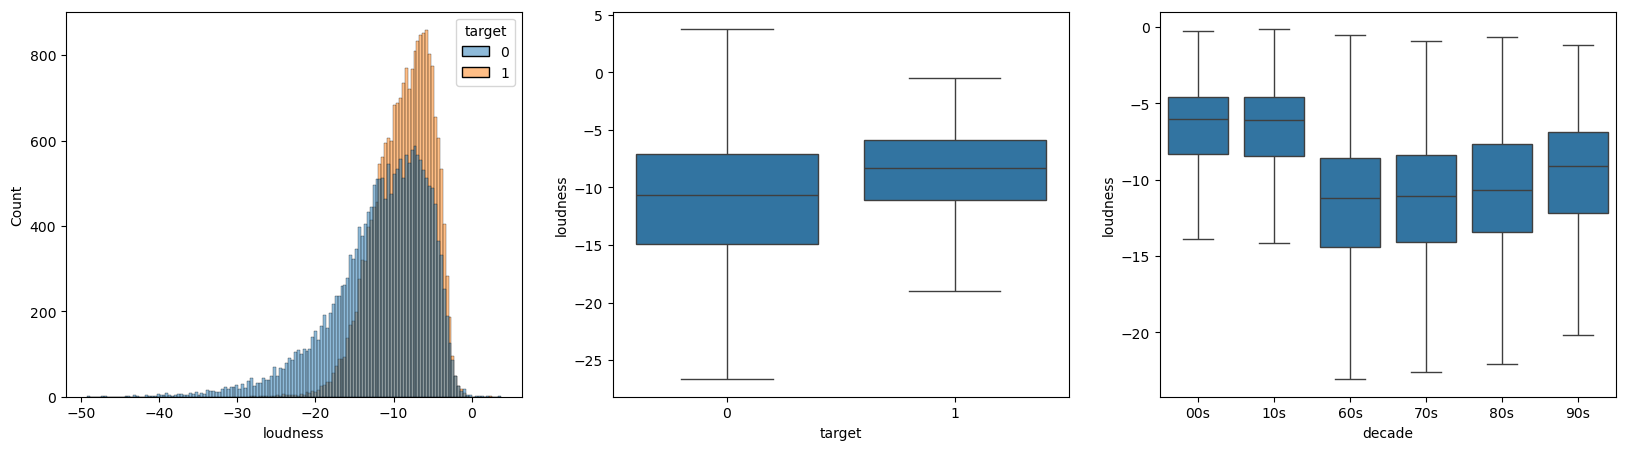

----------------------------------------------
For Variable - speechiness


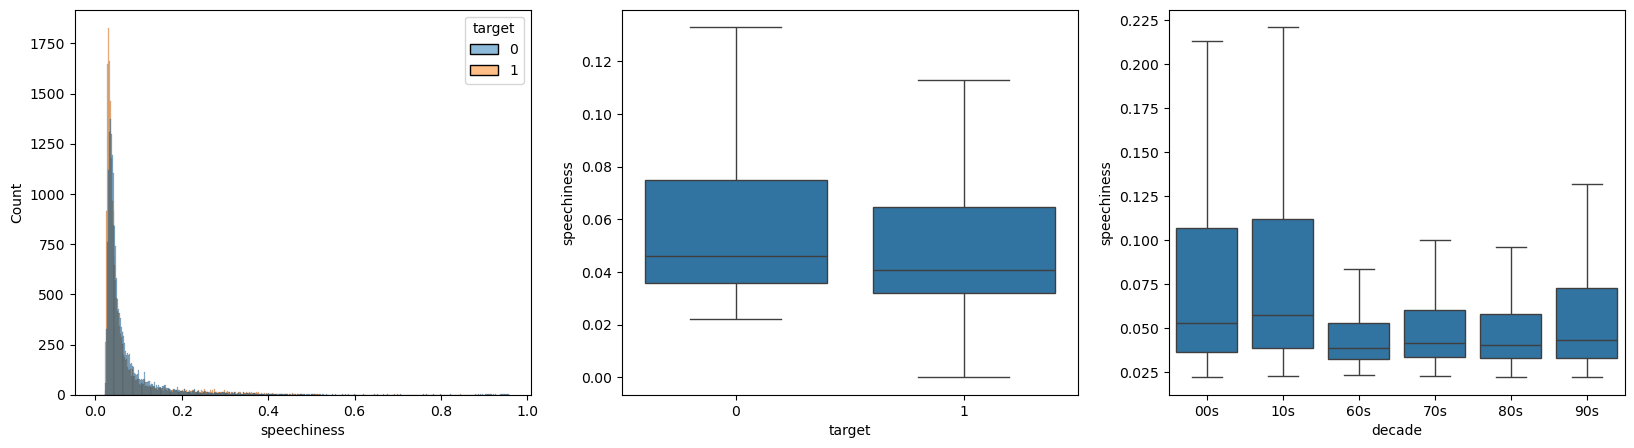

----------------------------------------------
For Variable - acousticness


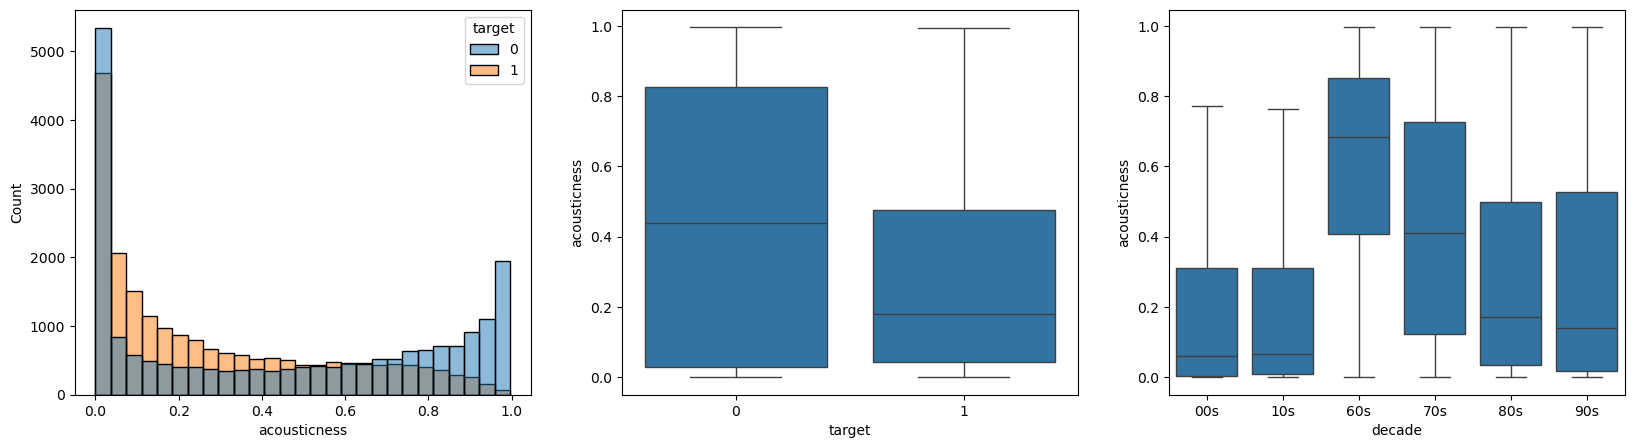

----------------------------------------------
For Variable - instrumentalness


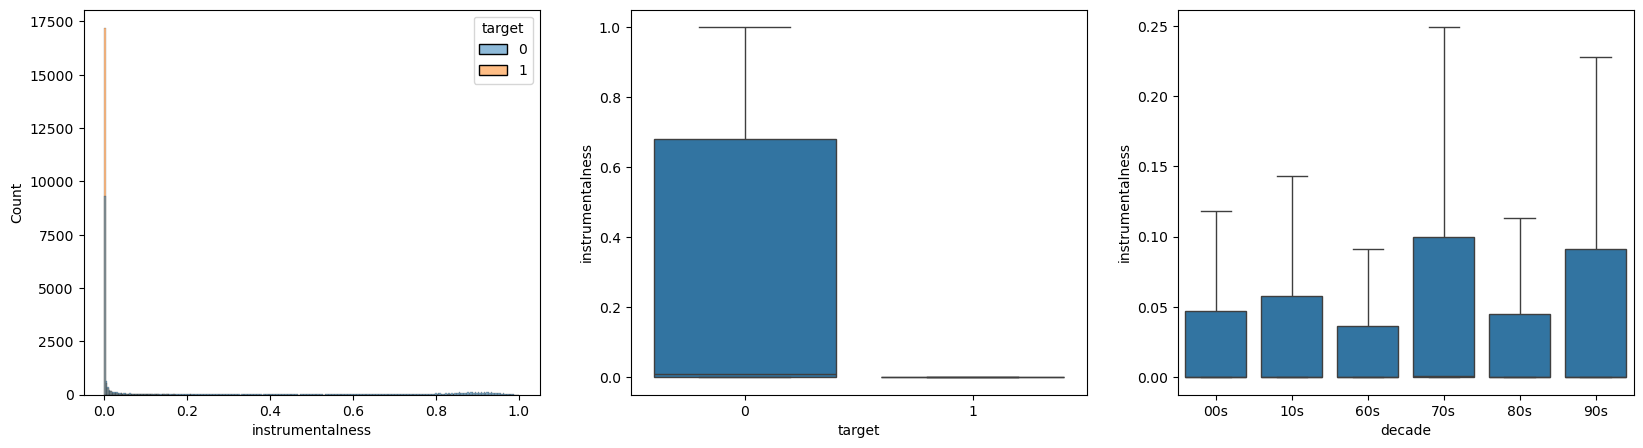

----------------------------------------------
For Variable - liveness


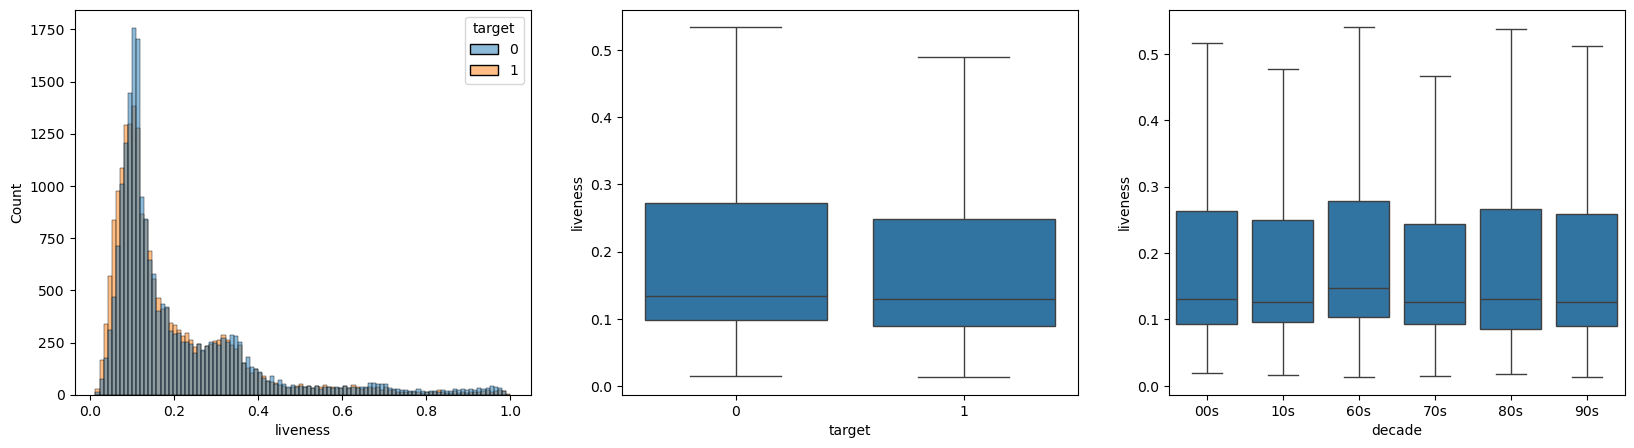

----------------------------------------------
For Variable - valence


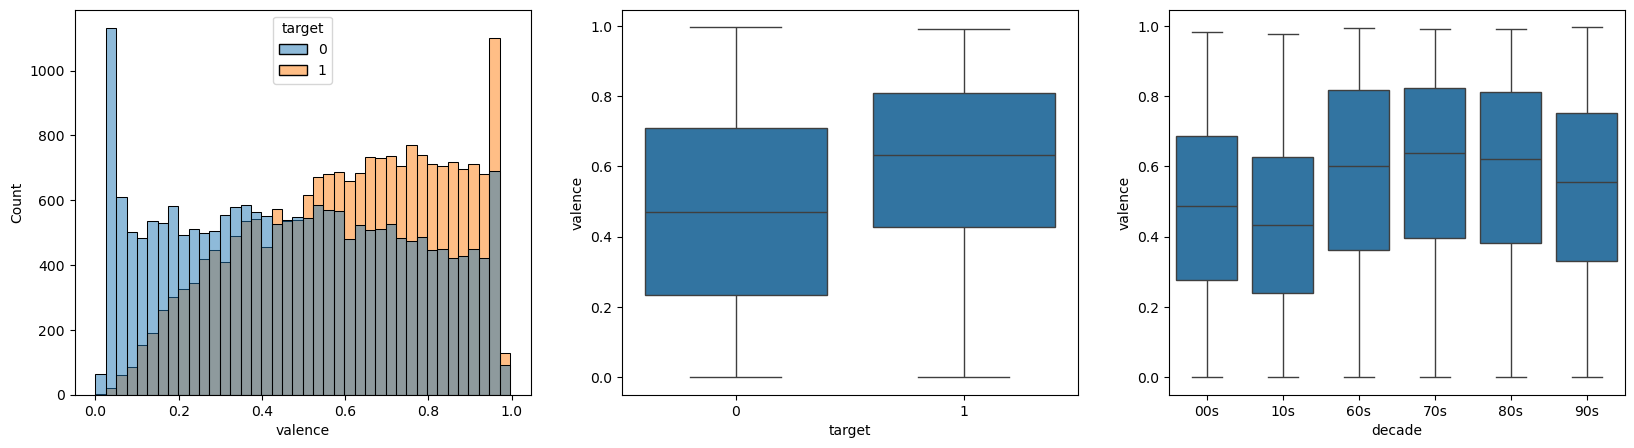

----------------------------------------------
For Variable - tempo


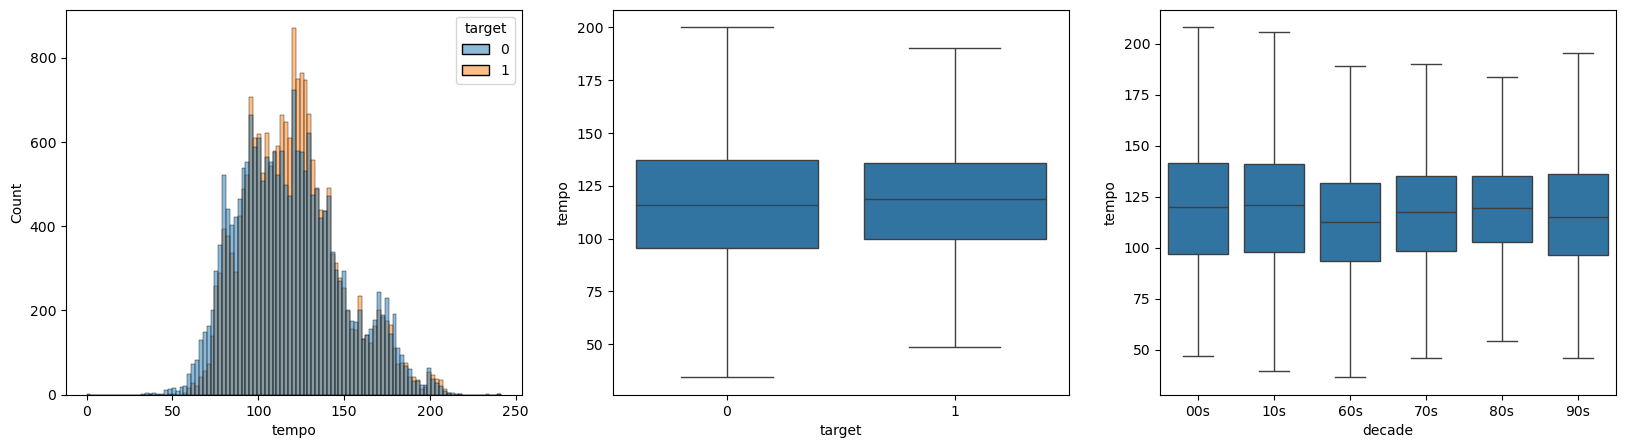

----------------------------------------------
For Variable - duration_ms


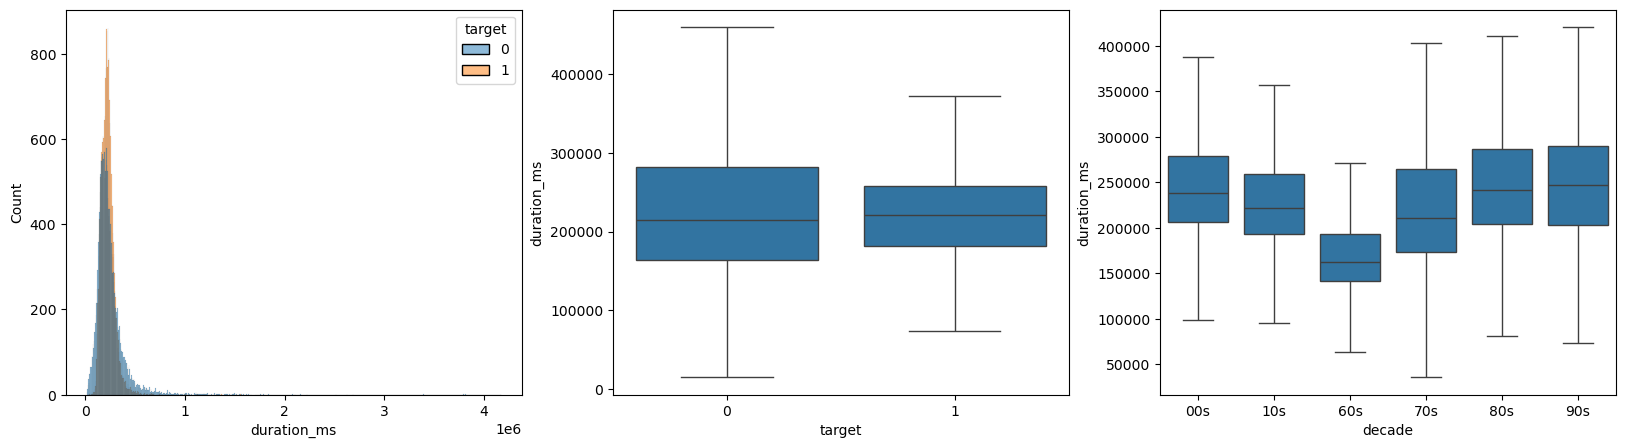

----------------------------------------------
For Variable - chorus_hit


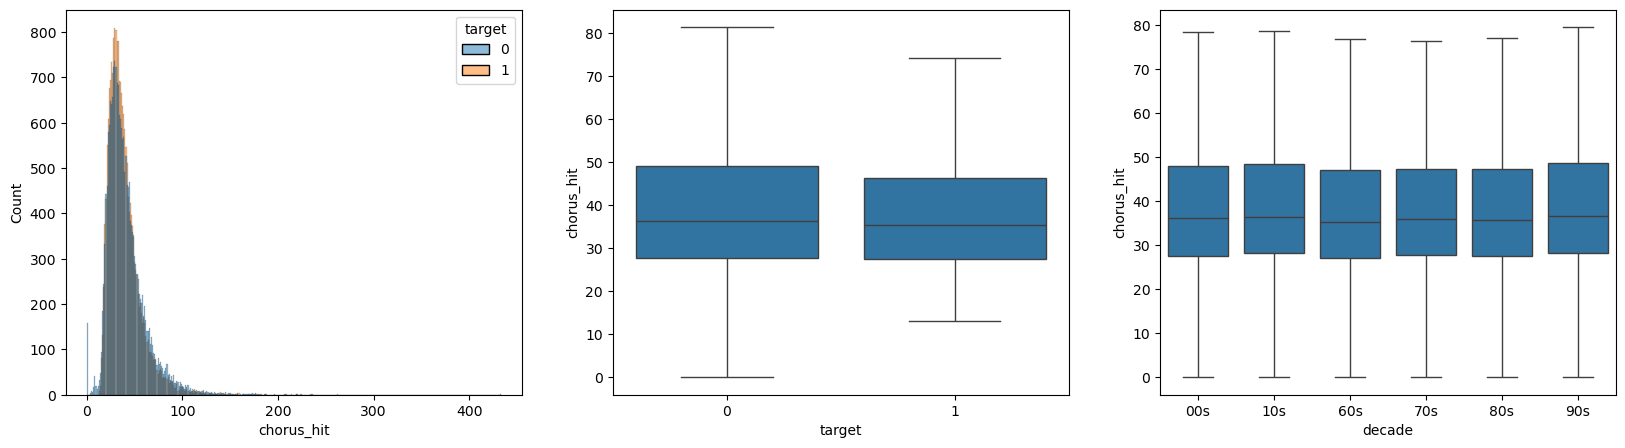

----------------------------------------------
For Variable - sections


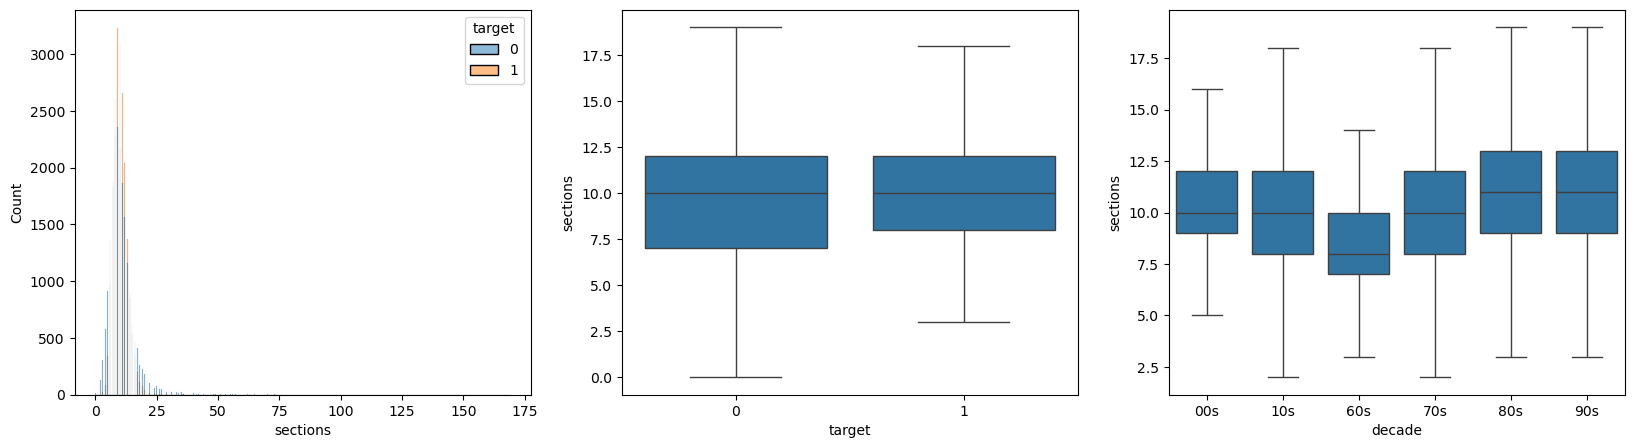

----------------------------------------------


In [19]:
for i in numerical_cols:
    print("For Variable - " + str(i))
    fig, axes = plt.subplots(1, 3, figsize=(20,5))
    sns.histplot(ax = axes[0], data=df_all, x=i, hue = "target")
    sns.boxplot(ax = axes[1], data=df_all, y=i, x = 'target', showfliers=False)
    sns.boxplot(ax = axes[2], data=df_all, y=i, x = 'decade', showfliers=False)
    plt.show()
    print("----------------------------------------------")

### Same Takeaways

#### 1. Hit songs seem to be more danceable! Let's test this hypothesis

In [22]:
s1 = df_all.loc[df_all.target == 1,'danceability'].values
s2 = df_all.loc[df_all.target == 0,'danceability'].values

In [23]:
ttest_dance = stats.ttest_ind(a=s1, b=s2, equal_var=True)
print(ttest_dance)
if(ttest_dance.pvalue < 0.01):
    print("It's Statistically Significant")

TtestResult(statistic=74.79015958357778, pvalue=0.0, df=41104.0)
It's Statistically Significant


#### 2. Hit songs seem to have an optimal range of energy
##### Also, we can see that 60s energy was lower than the most recent decades
##### T-test won't be valid here as the energy distribution for flop songs isnt normal and the means overlap. Let's use Mann-Whitney U test

In [25]:
s1 = df_all.loc[df_all.target == 1,'energy'].values
s2 = df_all.loc[df_all.target == 0,'energy'].values

In [26]:
stat, p = mannwhitneyu(s1, s2)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
    print("It's NOT Statistically Significant")
else:
    print("It's Statistically Significant")

Statistics=247391778.000, p=0.000
It's Statistically Significant


#### 3. Hit songs are more concentrated in terms of loudness compared to flop songs, which are relately more widely distributed
##### Let's test whether these samples are different

In [28]:
s1 = df_all.loc[df_all.target == 1,'loudness'].values
s2 = df_all.loc[df_all.target == 0,'loudness'].values

In [29]:
ttest_dance = stats.ttest_ind(a=s1, b=s2, equal_var=False)
print(ttest_dance)
if(ttest_dance.pvalue < 0.01):
    print("It's Statistically Significant")

TtestResult(statistic=60.51944378914351, pvalue=0.0, df=32984.8606333529)
It's Statistically Significant


#### 3. Hit songs have a different valence distribution compared to flop songs
##### Let's test whether these samples are different

In [31]:
s1 = df_all.loc[df_all.target == 1,'valence'].values
s2 = df_all.loc[df_all.target == 0,'valence'].values

In [32]:
stat, p = mannwhitneyu(s1, s2)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
    print("It's NOT Statistically Significant")
else:
    print("It's Statistically Significant")

Statistics=270095887.000, p=0.000
It's Statistically Significant


#### Now Let's test some categorical variables as well

In [59]:
def perform_chi_square_test(data, col1, col2):
    # Creating a contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])

    # Performing the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Interpreting the result
    if(p < 0.05):
        print("It's Significant")
    else:
        print("It's NOT Significant")

In [65]:
for i in categ_cols:
    print("For Variable: "+str(i))
    perform_chi_square_test(df_all, i, 'target')
    print("------------------------------")

For Variable: key
It's Significant
------------------------------
For Variable: mode
It's Significant
------------------------------
For Variable: time_signature
It's Significant
------------------------------
For Variable: decade
It's NOT Significant
------------------------------


In [31]:
df_all.dtypes

track                object
artist               object
uri                  object
danceability        float64
energy              float64
key                  object
loudness            float64
mode                 object
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature       object
chorus_hit          float64
sections              int64
target               object
decade               object
dtype: object

In [35]:
df_all.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target', 'decade'],
      dtype='object')

In [37]:
feature_cols = [ 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections']
target_col = 'target'

In [60]:
X = df_all[feature_cols]
y = df_all[target_col].astype(str)

In [62]:
y.unique()

array(['1', '0'], dtype=object)

In [39]:
from sklearn import model_selection, linear_model, ensemble, metrics

### Now, let's benchmark some of the most used models to compare them

In [64]:
class Benchmark:
    """
    This class allows to compare and evaluate the 
    performance of machine learning models using cross-validation
    
    Parameters
    ----------
    models : dict
      Dictionary of models, 
      where the key is the name of the model and
      the value is the model object.
    """

    def __init__(self, models):
        self.models = models

    def test_models(self, X=None, y=None, cv=5):
        """
        Test the models using the provided data and cross-validation.
        
        Parameters
        ----------
        X : array-like or DataFrame, shape (n_samples, n_features)
            Features for the test data.
        y : array-like or Series, shape (n_samples,)
            Target for the test data.
        cv : int, cross-validation generator or an iterable, optional
            Number of folds for the cross-validation.
        
        Returns
        -------
        best_model : str
            Name of the model with the highest score.
        """
        self.results = {}
        for name, model in self.models.items():
            scores = model_selection.cross_val_score(model, X, y, cv=cv)
            self.results[name] = scores.mean()
        self.best_model = max(self.results, key=self.results.get)
        return f"The best model is: {self.best_model} with a score of {self.results[self.best_model]:.3f}"

    def plot_cv_results(self):
        """
        Create a bar chart to visualize the cross-validation results.
        
        Returns
        -------
        None
        """
        plt.figure(figsize=(15,5))
        x = np.arange(len(self.results))
        plt.bar(x, list(self.results.values()), align='center', color ='g')
        plt.xticks(x, list(self.results.keys()))
        plt.ylim([0, 1])
        plt.ylabel('Cross-Validation Score')
        plt.xlabel('Models')
        plt.title('Model Comparison')
        for index, value in enumerate(self.results.values()):
            plt.text(index, value, str(round(value,2)))
        plt.show()

In [68]:
import warnings
warnings.filterwarnings('ignore')

The best model is: randomforest with a score of 0.774


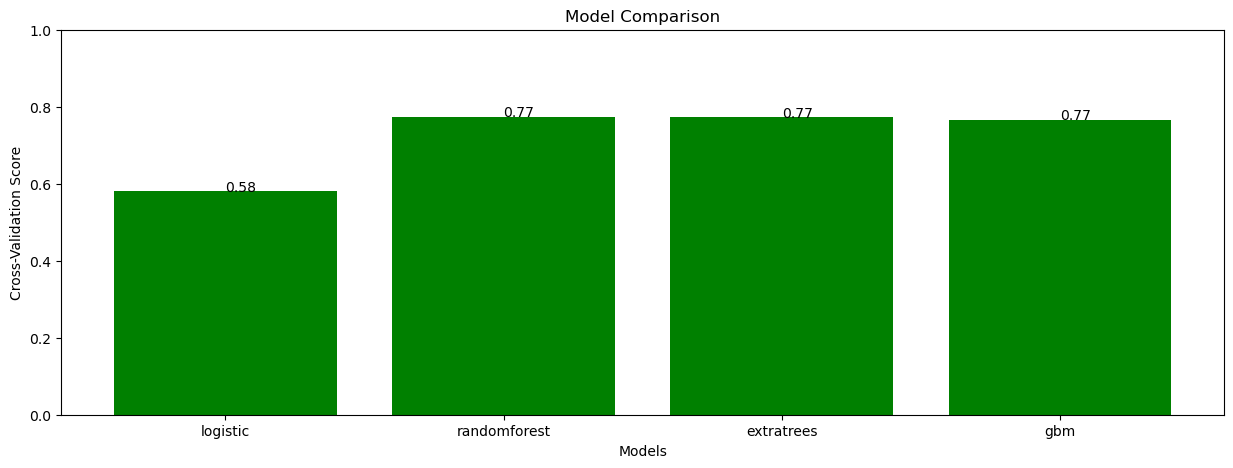

In [70]:
models = {
    'logistic': linear_model.LogisticRegression(),
    'randomforest': ensemble.RandomForestClassifier(),
    'extratrees': ensemble.ExtraTreesClassifier(),
    'gbm': ensemble.GradientBoostingClassifier()
}

benchmark = Benchmark(models)
print(benchmark.test_models(X,y))
benchmark.plot_cv_results()

### Let's use Random forest to construct the model

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

#### Tree based models don't require feature scaling

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

In [84]:
params = [{'n_estimators': [100,200,300],
         'max_depth': [5,6,7,8],
         'min_samples_split': [15, 20],
          'max_features':['sqrt','log2']}]

In [86]:
grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid=params, cv = 5)
grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)

RandomForestClassifier(max_depth=8, max_features='log2', min_samples_split=20,
                       n_estimators=200)


In [94]:
model_grid = RandomForestClassifier(max_depth=8,
                                    max_features="log2",
                                    min_samples_split=20,
                                    n_estimators=200)
model_grid.fit(X_train, y_train)
y_pred_grid = model_grid.predict(X_test)
print(classification_report(y_pred_grid, y_test))

              precision    recall  f1-score   support

           0       0.67      0.84      0.75      4168
           1       0.87      0.72      0.79      6109

    accuracy                           0.77     10277
   macro avg       0.77      0.78      0.77     10277
weighted avg       0.79      0.77      0.77     10277



In [102]:
feat_importances = pd.DataFrame(model_grid.feature_importances_, index=X.columns)

<Axes: >

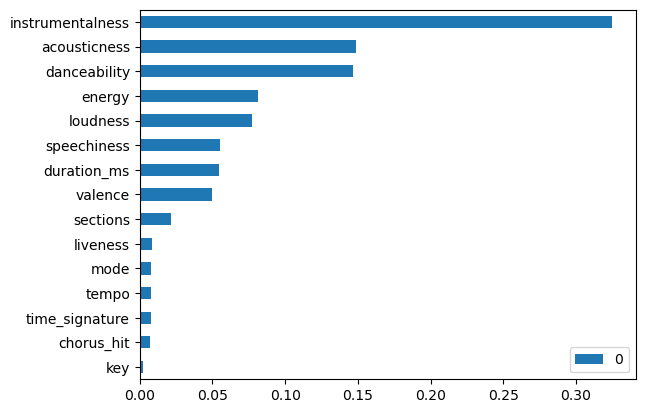

In [114]:
feat_importances.sort_values(by = 0).plot(kind = 'barh')